In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score



---



In [ ]:
df = pd.read_csv('/content/penguins_density.csv')
df.head()

,penguin_id,species,island,sex,year,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,1,Adelie,Torgersen,male,2007,39.1,18.7,181.0,3750.0
1,2,Adelie,Torgersen,female,2007,39.5,17.4,186.0,3800.0
2,3,Adelie,Torgersen,female,2007,40.3,18.0,195.0,3250.0
3,4,Adelie,Torgersen,female,2007,36.7,19.3,193.0,3450.0
4,5,Adelie,Torgersen,male,2007,39.3,20.6,190.0,3650.0


In [ ]:
X = df[['bill_depth_mm', 'flipper_length_mm']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

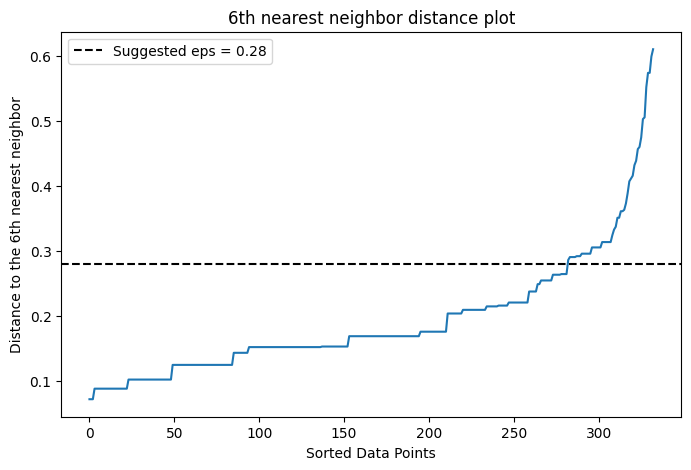

In [ ]:
neighbors_model = NearestNeighbors(n_neighbors=6)
neighbors_model.fit(X_scaled)

distances, indices = neighbors_model.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(kth_distances)
plt.title("6th nearest neighbor distance plot")
plt.xlabel("Sorted Data Points")
plt.ylabel("Distance to the 6th nearest neighbor")
plt.axhline(y=0.28, color='black', linestyle='--', label=f'Suggested eps = 0.28')
plt.legend()
plt.show()

In [ ]:
dbscan_model = DBSCAN(eps=0.28, min_samples=6)
df["dbscan_cluster"] = dbscan_model.fit_predict(X_scaled)

dbscan_n_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in set(df["dbscan_cluster"]) else 0)

dbscan_noise_count = int((df["dbscan_cluster"] == -1).sum())

dbscan_mask = df["dbscan_cluster"] != -1
dbscan_silhouette = silhouette_score(
    X_scaled[dbscan_mask],
    df.loc[dbscan_mask, "dbscan_cluster"]
)

print(f"DBSCAN clusters found: {dbscan_n_clusters}")
print(f"Noise points found: {dbscan_noise_count}")
print(f"DBSCAN silhouette score (non-noise rows only): {dbscan_silhouette:.4f}")


DBSCAN clusters found: 3
Noise points found: 24
DBSCAN silhouette score (non-noise rows only): 0.4206


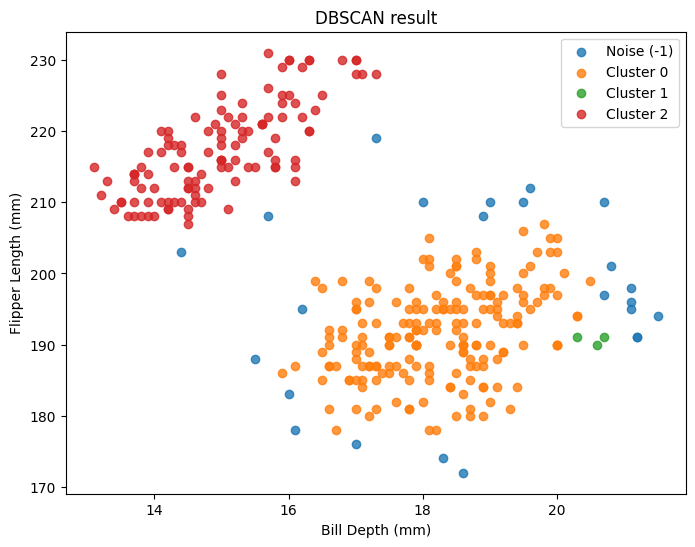

In [ ]:
plt.figure(figsize=(8, 6))

for label in sorted(df["dbscan_cluster"].unique()):
    subset = df[df["dbscan_cluster"] == label]
    if label == -1:
        label_name = "Noise (-1)"
    else:
        label_name = f"Cluster {label}"

    plt.scatter(
        subset["bill_depth_mm"],
        subset["flipper_length_mm"],
        alpha=0.8,
        label=label_name
    )

plt.title("DBSCAN result")
plt.xlabel("Bill Depth (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend()
plt.show()

In [ ]:
meanshift_model = MeanShift(bandwidth=0.55, bin_seeding=True)
df["meanshift_cluster"] = meanshift_model.fit_predict(X_scaled)

meanshift_n_clusters = len(np.unique(df["meanshift_cluster"]))
meanshift_silhouette = silhouette_score(X_scaled, df["meanshift_cluster"])

print(f"Mean Shift clusters found: {meanshift_n_clusters}")

meanshift_noise_count = int((df["meanshift_cluster"] == -1).sum())
print(f"Noise points found: {meanshift_noise_count}")

print(f"Mean Shift silhouette score: {meanshift_silhouette:.4f}")


Mean Shift clusters found: 3
Noise points found: 0
Mean Shift silhouette score: 0.5551


In [ ]:
meanshift_centers = pd.DataFrame(
    scaler.inverse_transform(meanshift_model.cluster_centers_),
    columns=['bill_depth_mm', 'flipper_length_mm']
).round(2)

meanshift_centers.index.name = "cluster"

print("Mean Shift cluster centers in the original units:")
display(meanshift_centers)

Mean Shift cluster centers in the original units:


,bill_depth_mm,flipper_length_mm
cluster,,
0,18.43,192.12
1,14.35,213.24
2,15.33,219.06


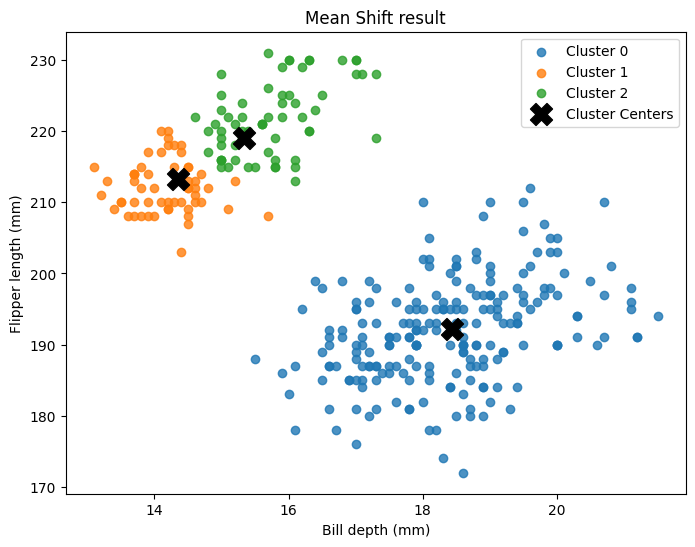

In [ ]:
plt.figure(figsize=(8, 6))

for label in sorted(df["meanshift_cluster"].unique()):
    subset = df[df["meanshift_cluster"] == label]
    plt.scatter(
        subset["bill_depth_mm"],
        subset["flipper_length_mm"],
        alpha=0.8,
        label=f"Cluster {label}"
    )

plt.scatter(
    meanshift_centers["bill_depth_mm"],
    meanshift_centers["flipper_length_mm"],
    marker="X",
    s=250,
    c="black",
    label="Cluster Centers"
)

plt.title("Mean Shift result")
plt.xlabel("Bill depth (mm)")
plt.ylabel("Flipper length (mm)")
plt.legend()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "method": ["DBSCAN", "Mean Shift"],
    "main_settings": ["eps=0.28, min_samples=6", "bandwidth=0.55"],
    "clusters_found": [dbscan_n_clusters, meanshift_n_clusters],
    "noise_points": [dbscan_noise_count, 0],
    "silhouette_score": [dbscan_silhouette, meanshift_silhouette]
}).round(4)

print("Method comparison:")
display(comparison_df)

Method comparison:


,method,main_settings,clusters_found,noise_points,silhouette_score
0,DBSCAN,"eps=0.28, min_samples=6",3,24,0.4206
1,Mean Shift,bandwidth=0.55,3,0,0.5551




---



DBSCAN is a clustering algorithm that can be used for noise/outlier detection, therefore, some instances are left without labeling. Mean Shift, on the other hand, assigns every instance to a cluster by shifting data points toward the region of highest density, making it a more complete clustering approach with no noise points.
Although both methods produced three clusters, Mean Shift clusters appear to be more natural and well-separated, but DBSCAN clusters are different; cluster number 1 appears to be part of cluster 0 on the plot.